# Medikal Görüntü İşleme 10. Hafta Ödev
Geometrik dönüşümler yapılırken oluşan görüntünün anatomik olarak uygun olması gerekir. Aksi durumda model performansı düşebilir. Yaptığımız işlemleri buna dikkat ederek yaptık.

Aşağıda işlemleri ve detaylı açıklamalarını verdik.



In [8]:
import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
from PIL import Image
from google.colab import files
import cv2

### **Yatay ve Dikey Döndürme**

In [ ]:
mr_image = files.upload()
mr_dosya = list(mr_image.keys())[0]
image = np.array(Image.open(mr_dosya).convert("L"))

Saving 694.png to 694.png


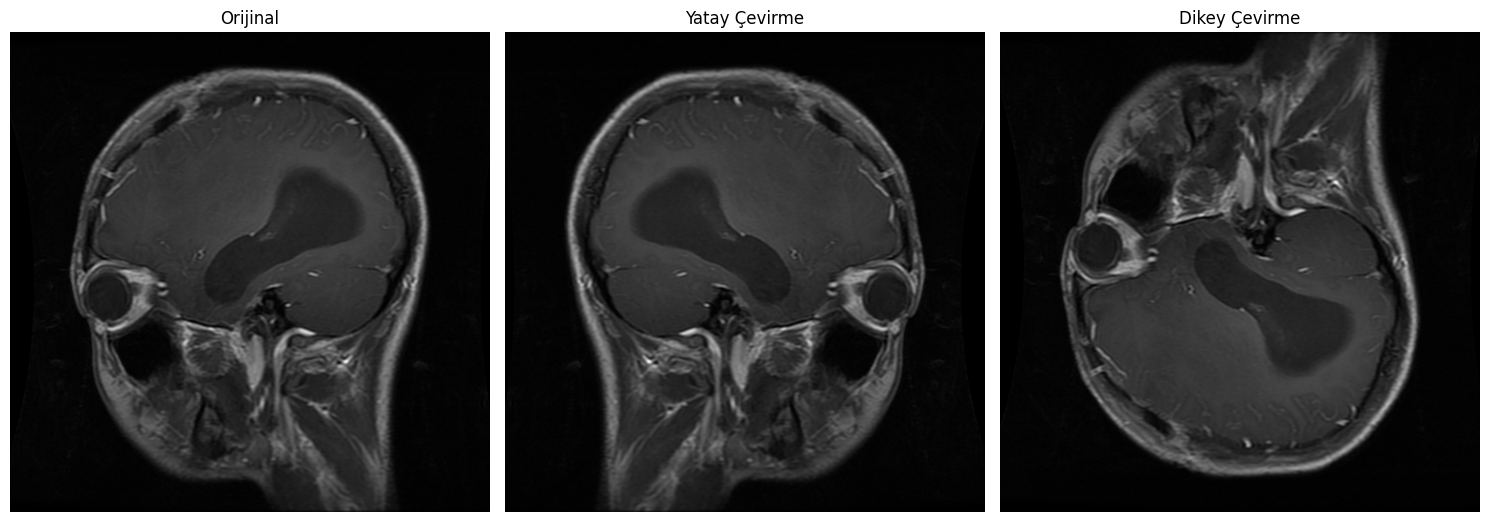

In [ ]:
transforms = {
    "Orijinal": None,
    "Yatay Çevirme": A.HorizontalFlip(p=1),
    "Dikey Çevirme": A.VerticalFlip(p=1),
    }
results = {}
results["Orijinal"] = image
for name, tf in transforms.items():
    if name != "Orijinal" and tf is not None:
        results[name] = tf(image=image)["image"]

# Göster
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, img) in enumerate(results.items()):
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Yukarıda yatay ve dikey döndürme işlemleri yaptık. Yatay döndürme işleminin modele pozitif yönde katkısı bulunabilir ama aynı durum dikey döndürme işlemi için söylenemez. Çünkü beynin sağ ve sol lobu simetriktir bu durumda yatayda döndürme işlemi yapıldığında biyolojik olarak anormal bir görüntü elde etmeyiz. Dikey döndürme işleminde ise bu durum model eğitimi açısından sıkıntı oluşturabilir çünkü görüntüyü dikeyde döndürdüğümüzde biyolojik olarak anormal bir görüntü elde ederiz.

### **Döndürme (Rotation) İşlemleri**

In [6]:
mr_image = files.upload()
mr_dosya = list(mr_image.keys())[0]
image = np.array(Image.open(mr_dosya).convert("L"))

Saving 611.png to 611 (1).png


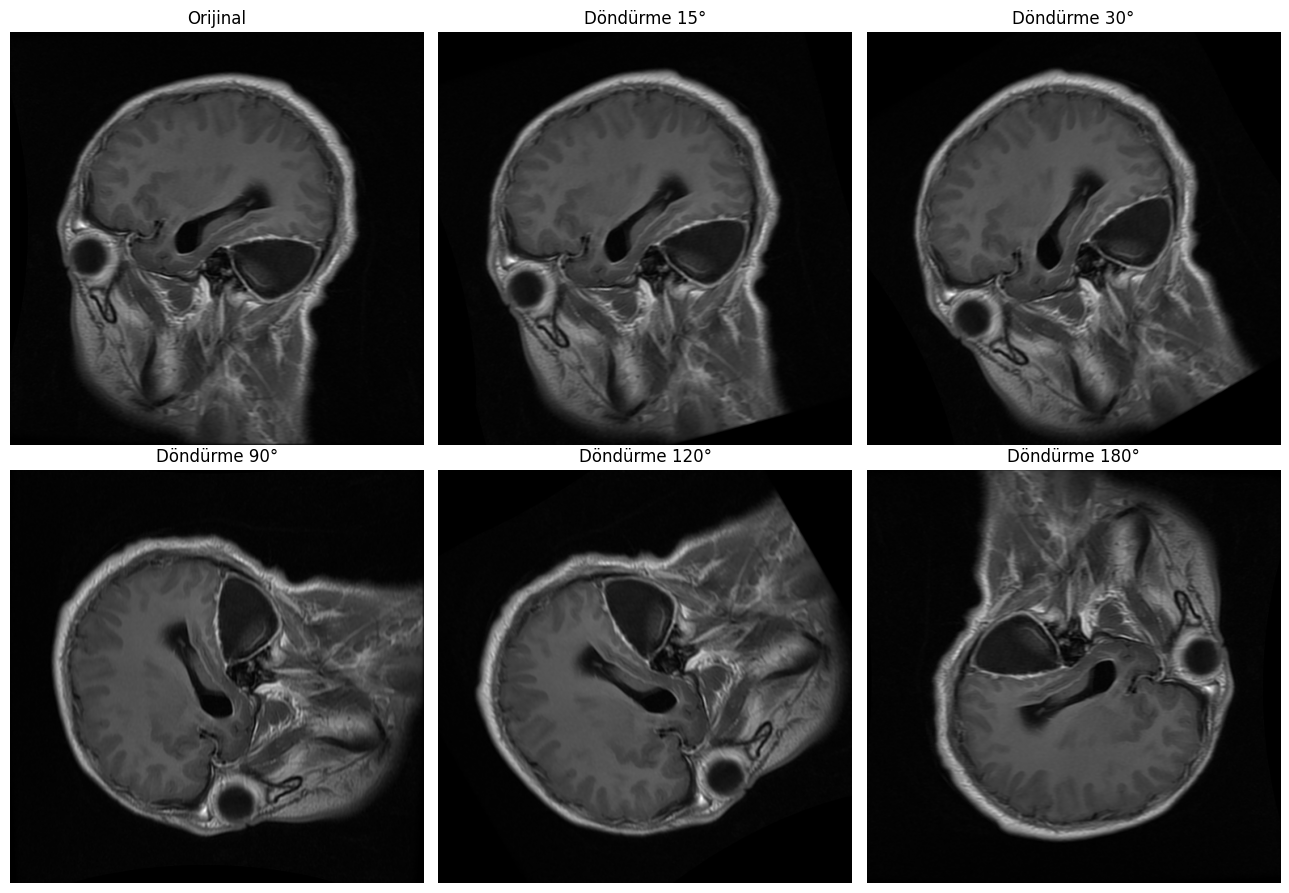

In [4]:
transforms = {
    "Orijinal": None,
    "Döndürme 15°": A.Affine(rotate=15, p=1),
    "Döndürme 30°": A.Affine(rotate=30, p=1),
    "Döndürme 90°": A.Affine(rotate=90, p=1),
    "Döndürme 120°": A.Affine(rotate=120, p=1),
    "Döndürme 180°": A.Affine(rotate=180, p=1),

}

results = {}
results["Orijinal"] = image
for name, tf in transforms.items():
    if name != "Orijinal" and tf is not None:
        results[name] = tf(image=image)["image"]

# Göster
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
axes = axes.flatten()

for i, (name, img) in enumerate(results.items()):
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Yukarıda Affine ile döndürme işlemleri gerçekleştirdik. Bizim verilerimiz için (beyin MR görüntüsü) 20°'ye kadar olan dönüşümler model için uygun olabilir ancak daha büyük açılarla dönüşüm anatomik olarak gerçekçi olmayacağı  için model performansını düşürebilir. Bu yüzden dönüşümler yapılırken verinin uygunluğuna dikkat edilmelidir.

### **Öteleme (Translation) İşlemi**

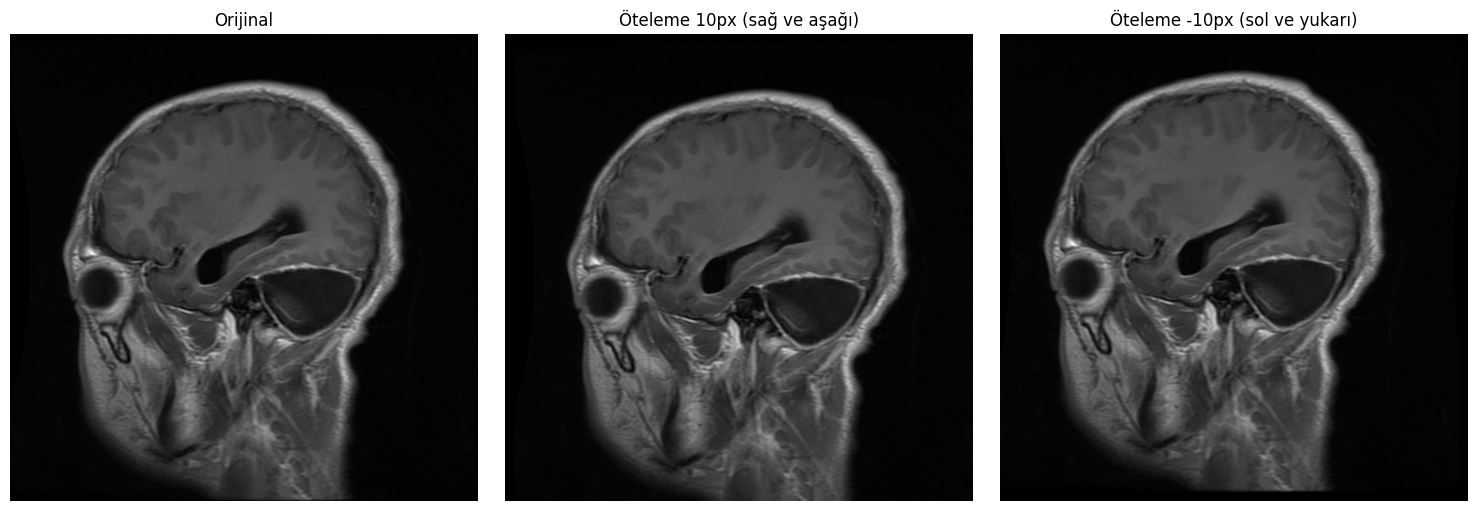

In [7]:
transforms = {
    "Orijinal": None,
    "Öteleme 10px (sağ ve aşağı)": A.Affine(translate_px=10, p=1),
    "Öteleme -10px (sol ve yukarı)": A.Affine(translate_px=-10, p=1),
}
results = {}
results["Orijinal"] = image
for name, tf in transforms.items():
    if name != "Orijinal" and tf is not None:
        results[name] = tf(image=image)["image"]

# Göster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, (name, img) in enumerate(results.items()):
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

MR görüntüsünde hasta her zaman merkezde olmayabilir, öteleme işlemiyle model tümörün mutlak konum yerine göreceli konumu öğrenmesi hedeflenir.

Öteleme işleminin fazla yapılması tümörün görüntü alanının dışına çıkmasına neden olabilir bu yüzden öteleme işlemi yapılırken bunlara dikkat edilmelidir.

MR görüntüleri üzerinde ölçekleme, esnetme gibi işlemler de yapılabilir. Ölçekleme ile görüntüyü büyütebilir ve küçültebiliriz. Tümörün farklı boyutlarda nasıl görünebileceğini öğrenmesi açısından bu işlemler model için faydalı veri artırma yöntemleri olabilir.  Ancak yine fazla büyütme ve küçültme model performansını düşürebilir.

Esnetme ile tümör şeklinde değişiklikler yapabiliriz ama burada görüntünün fazla bozulmamasına dikkat edilmelidir. Anatomik olarak görüntünün uygun olmaması modelin yanlış öğrenmesine ve performans kaybına neden olabilir.

### **Farklı Dönüşüm Kombinasyonları**

Aşağıda bir görüntü üzerinde birkaç dönüşüm işlemi yaparak veri artırma (data augmentation) örneği gerçekleştirdik.

In [9]:
mr_image = files.upload()
mr_dosya = list(mr_image.keys())[0]
image = np.array(Image.open(mr_dosya).convert("L"))

Saving 605.png to 605.png


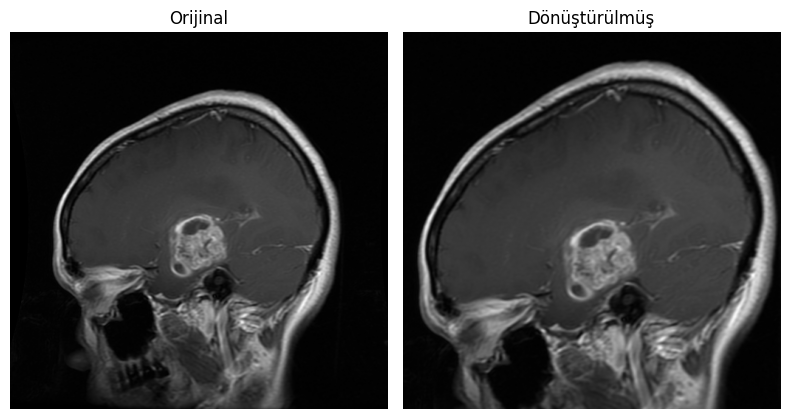

In [10]:
transform = A.Affine(
    scale=1.25,
    shear=2,
    rotate=5,
    translate_px=10,
    p=1.0
)

result = transform(image=image)["image"]

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Orijinal")
axes[0].axis("off")

axes[1].imshow(result, cmap="gray")
axes[1].set_title("Dönüştürülmüş")
axes[1].axis("off")

plt.tight_layout()
plt.show()

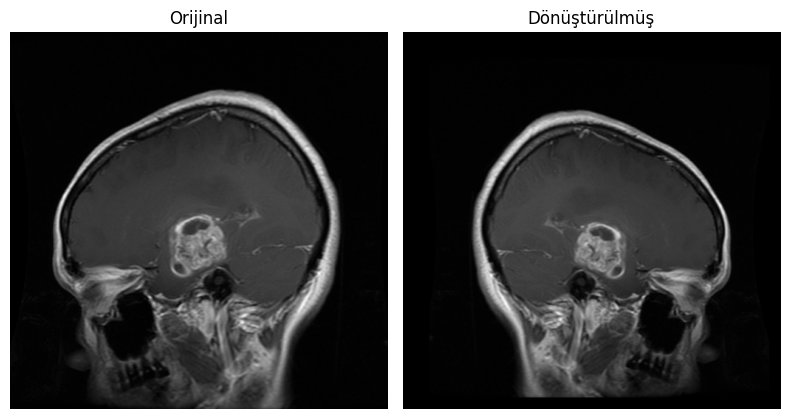

In [11]:
transform = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Affine(
        scale=0.9,
        translate_px=10,
        p=1.0
    )
])

result = transform(image=image)["image"]

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Orijinal")
axes[0].axis("off")

axes[1].imshow(result, cmap="gray")
axes[1].set_title("Dönüştürülmüş")
axes[1].axis("off")

plt.tight_layout()
plt.show()

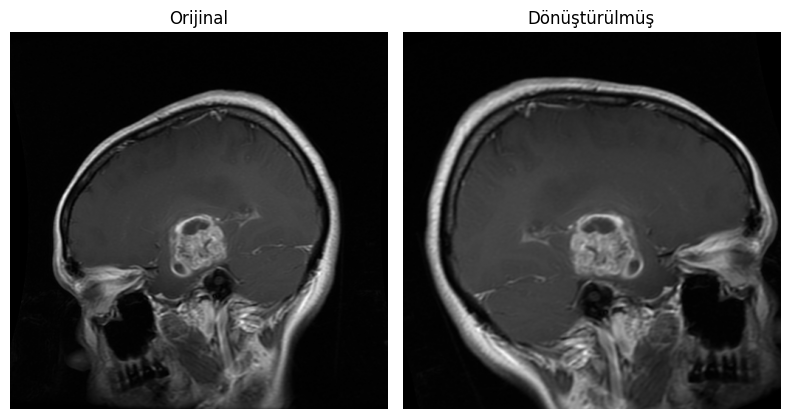

In [12]:
transform = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Affine(
        scale=1.2,
        rotate=20,
        p=1.0
    )
])

result = transform(image=image)["image"]

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Orijinal")
axes[0].axis("off")

axes[1].imshow(result, cmap="gray")
axes[1].set_title("Dönüştürülmüş")
axes[1].axis("off")

plt.tight_layout()
plt.show()

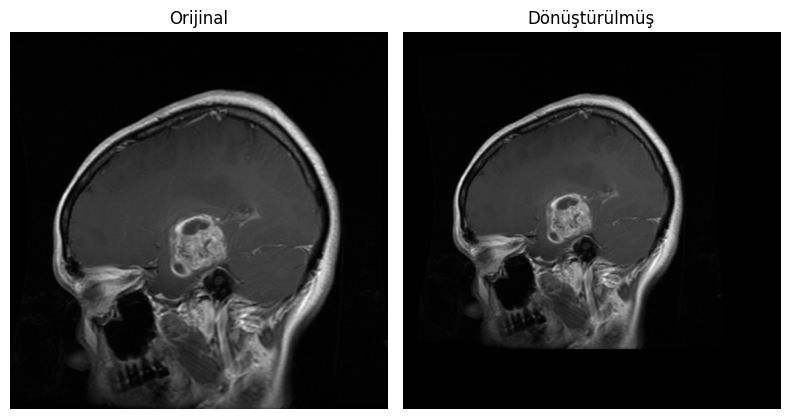

In [15]:
transform = A.Affine(
        scale=0.8,
        translate_px=-30,
        p=1.0
    )


result = transform(image=image)["image"]

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Orijinal")
axes[0].axis("off")

axes[1].imshow(result, cmap="gray")
axes[1].set_title("Dönüştürülmüş")
axes[1].axis("off")

plt.tight_layout()
plt.show()